**Cell 1: Environment Setup, Dependencies & Data Downloading**

In [1]:
import os
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import hashlib
import re
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Dataset, Subset
from torchvision import models, datasets
from torchvision.transforms import v2, transforms

from sklearn.preprocessing import StandardScaler, Normalizer
from sklearn.svm import SVC
from sklearn.neighbors import NearestCentroid
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_curve, auc
from sklearn.preprocessing import label_binarize
from sklearn.manifold import TSNE
import pandas as pd
import matplotlib.image as mpimg

warnings.filterwarnings("ignore")

# Download datasets & install Grad-CAM
!pip install -q kagglehub grad-cam

import kagglehub

print("Downloading training dataset (ucimachinelearning/otoscopic-image-dataset)...")
ORIGINAL_DATASET_PATH = kagglehub.dataset_download(
    "ucimachinelearning/otoscopic-image-dataset"
)
print(f"  -> saved to: {ORIGINAL_DATASET_PATH}")

class PipelineConfig:
    ORIGINAL_DATA_DIR = ORIGINAL_DATASET_PATH
    BATCH_SIZE = 32
    SEED = 42
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    TARGET_CLASSES = [
        'Acute Otitis Media',
        'Cerumen Impaction',
        'Chronic Otitis Media',
        'Myringosclerosis',
        'Normal'
    ]

    CLASS_MAPPING = {
        'Acute Otitis Media': 0,
        'Cerumen Impaction': 1,
        'Earwax plug': 1,
        'Chronic Otitis Media': 2,
        'Chronic otitis media': 2,
        'Myringosclerosis': 3,
        'Normal': 4
    }

config = PipelineConfig()

# Reproducibility enforcement
os.environ['PYTHONHASHSEED'] = str(config.SEED)
random.seed(config.SEED)
np.random.seed(config.SEED)
torch.manual_seed(config.SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(config.SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.5/44.5 kB 2.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Using Colab cache for faster access to the 'otoscopic-image-dataset' dataset.
  -> saved to: /kaggle/input/otoscopic-image-dataset


**Cell 2: Data Augmentation, Mapping & Data Loaders**

In [2]:
train_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize(256, antialias=True),
    v2.RandomResizedCrop(224, scale=(0.85, 1.0)),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=15),
    v2.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize(256, antialias=True),
    v2.CenterCrop(224),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

def find_image_folder_root(directory, min_classes=2):
    image_exts = ('.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff')
    for root, dirs, files in os.walk(directory):
        dirs.sort()
        candidate_classes = [d for d in dirs if any(f.lower().endswith(image_exts) for f in os.listdir(os.path.join(root, d)))]
        if len(candidate_classes) >= min_classes: return root
    return directory

def classify_folder_name(class_name, mapping):
    if class_name in mapping: return mapping[class_name]
    normalized = re.sub(r'[^a-z0-9\s]', ' ', class_name.lower()).strip()
    tokens = set(normalized.split())
    if ('cholesteatoma' in normalized or 'caom' in tokens or 'ciom' in tokens): return mapping.get('Chronic Otitis Media')
    if 'aom' in tokens: return mapping.get('Acute Otitis Media')
    if 'cerumen' in normalized or 'wax' in tokens: return mapping.get('Cerumen Impaction')
    if 'myringosclerosis' in normalized: return mapping.get('Myringosclerosis')
    if 'normal' in tokens: return mapping.get('Normal')
    return None

class BaseMappedDataset(Dataset):
    def __init__(self, directory, mapping):
        resolved_dir = find_image_folder_root(directory)
        self.full_dataset = datasets.ImageFolder(root=resolved_dir)
        self.mapping = mapping
        self.samples = [(path, classify_folder_name(c, mapping)) for path, orig_idx in self.full_dataset.samples if (c := self.full_dataset.classes[orig_idx]) and classify_folder_name(c, mapping) is not None]

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx):
        path, label = self.samples[idx]
        return self.full_dataset.loader(path), label, path

class TransformSubset(Dataset):
    def __init__(self, subset, transform):
        self.subset = subset
        self.transform = transform
    def __len__(self): return len(self.subset)
    def __getitem__(self, idx):
        img, label, path = self.subset[idx]
        return self.transform(img), label, path

def build_data_loaders():
    base_dataset = BaseMappedDataset(config.ORIGINAL_DATA_DIR, config.CLASS_MAPPING)

    # Deduplication
    unique_indices, seen_hashes = [], set()
    for idx in range(len(base_dataset)):
        with open(base_dataset.samples[idx][0], "rb") as f:
            img_hash = hashlib.md5(f.read()).hexdigest()
        if img_hash not in seen_hashes:
            seen_hashes.add(img_hash)
            unique_indices.append(idx)

    clean_dataset = Subset(base_dataset, unique_indices)
    total_count = len(clean_dataset)

    train_size = int(0.70 * total_count)
    val_size = int(0.15 * total_count)
    test_size = total_count - train_size - val_size

    raw_train, raw_val, raw_test = random_split(
        clean_dataset, [train_size, val_size, test_size],
        generator=torch.Generator().manual_seed(config.SEED)
    )

    train_dataset = TransformSubset(raw_train, train_transforms)
    val_dataset = TransformSubset(raw_val, test_transforms)
    test_dataset = TransformSubset(raw_test, test_transforms)

    return (DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True, num_workers=2),
            DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=2),
            DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False, num_workers=2))

train_loader, val_loader, test_loader = build_data_loaders()

**Cell 3: Multi-Backbone Feature Extraction & SVM Ablation Study**

In [3]:
def extract_deep_features(loader, extraction_model, run_device):
    extraction_model.eval()
    features, labels, paths = [], [], []
    with torch.no_grad():
        for inputs, targets, img_paths in tqdm(loader, desc="Extracting"):
            inputs = inputs.to(run_device)
            embeddings = extraction_model(inputs)
            features.append(embeddings.view(embeddings.size(0), -1).cpu().numpy())
            labels.append(targets.numpy())
            paths.extend(img_paths)
    return np.concatenate(features, axis=0), np.concatenate(labels, axis=0), paths

architectures = {
    'ResNet-101': nn.Sequential(
        *list(models.resnet101(weights=models.ResNet101_Weights.IMAGENET1K_V2).children())[:-1]
    ),
    'DenseNet-121': nn.Sequential(
        models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1).features,
        nn.ReLU(inplace=True),
        nn.AdaptiveAvgPool2d((1, 1))
    ),
    'EfficientNet-B3': nn.Sequential(
        *list(models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1).children())[:-1],
        nn.AdaptiveAvgPool2d((1, 1))
    )
}

trained_svms = {}
fitted_scalers = {}
results_dict = {}

test_paths_final = None
classifier = None
scaler_final = None
X_test_scaled_final = None
y_test_final = None

for model_name, backbone in architectures.items():
    print(f"\n[{model_name}] Extracting Features & Training SVM...")
    extractor = backbone.to(config.DEVICE)

    X_train, y_train, _ = extract_deep_features(train_loader, extractor, config.DEVICE)
    X_test, y_test, test_paths = extract_deep_features(test_loader, extractor, config.DEVICE)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    svm = SVC(C=1.0, kernel='rbf', class_weight='balanced', probability=True, random_state=config.SEED)
    svm.fit(X_train_scaled, y_train)

    acc = svm.score(X_test_scaled, y_test)
    results_dict[model_name] = acc

    trained_svms[model_name] = svm
    fitted_scalers[model_name] = scaler

    print(f"-> {model_name} + SVM Test Accuracy: {acc:.4f}")

    if model_name == 'ResNet-101':
        X_test_scaled_final, y_test_final = X_test_scaled, y_test
        test_paths_final = test_paths  # Correctly stored for Cell 10
        classifier = svm
        scaler_final = scaler

X_test_scaled = X_test_scaled_final
y_test = y_test_final

print("\n=== ABLATION STUDY RESULTS FOR PAPER ===")
for model, accuracy in results_dict.items():
    print(f"{model} Feature Extractor: {accuracy*100:.2f}%")

Downloading: "https://download.pytorch.org/models/resnet101-cd907fc2.pth" to /root/.cache/torch/hub/checkpoints/resnet101-cd907fc2.pth


100%|██████████| 171M/171M [00:02<00:00, 74.6MB/s]


Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 70.9MB/s]


Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth


...

-> ResNet-101 + SVM Test Accuracy: 0.9818

[DenseNet-121] Extracting Features & Training SVM...


Extracting: 100%|██████████| 14/14 [00:02<00:00,  6.12it/s]


-> DenseNet-121 + SVM Test Accuracy: 0.9658

[EfficientNet-B3] Extracting Features & Training SVM...


Extracting: 100%|██████████| 14/14 [00:02<00:00,  6.69it/s]


-> EfficientNet-B3 + SVM Test Accuracy: 0.9932

=== ABLATION STUDY RESULTS FOR PAPER ===
ResNet-101 Feature Extractor: 98.18%
DenseNet-121 Feature Extractor: 96.58%
EfficientNet-B3 Feature Extractor: 99.32%


**CELL 3-B: LIGHTGBM COMPARATIVE EVALUATION**

In [4]:
import lightgbm as lgb
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score

print("\n=== Training LightGBM Classifier on ResNet-101 Features ===")

# Initialize LightGBM with balanced class weights to match the SVM setup
lgbm_clf = lgb.LGBMClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=6,
    class_weight='balanced',
    random_state=config.SEED,
    n_jobs=-1
)

# Fit model on unscaled or scaled features (tree models are scale-invariant)
lgbm_clf.fit(X_train, y_train)

# Evaluate on test set
y_pred_lgbm = lgbm_clf.predict(X_test)
y_probs_lgbm = lgbm_clf.predict_proba(X_test)

lgbm_acc = accuracy_score(y_test, y_pred_lgbm)
lgbm_auc = roc_auc_score(y_test, y_probs_lgbm, multi_class='ovr')

print(f"LightGBM Test Accuracy: {lgbm_acc * 100:.2f}%")
print(f"LightGBM Multi-class ROC-AUC (OvR): {lgbm_auc:.4f}")

print("\n--- LightGBM Classification Report ---")
print(classification_report(y_test, y_pred_lgbm, target_names=config.TARGET_CLASSES, digits=4))

# Store results for model comparison table
results_dict['ResNet-101 + LightGBM'] = lgbm_acc


=== Training LightGBM Classifier on ResNet-101 Features ===
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.039531 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 391680
[LightGBM] [Info] Number of data points in the train set: 2045, number of used features: 1536
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

**Cell 4: Domain-Aligned External Dataset Validation**

=== Downloading OtitisMediaKPJ Dataset via kagglehub ===


100%|██████████| 62.4M/62.4M [00:00<00:00, 156MB/s]

Extracting files...


Loaded 468 external samples with aligned class labels.

[ResNet-101] Extracting Domain-Normalized Features...


Extracting: 100%|██████████| 15/15 [00:03<00:00,  4.00it/s]


-> ResNet-101 Domain-Aligned External Accuracy: 83.97%
                      precision    recall  f1-score   support

  Acute Otitis Media     0.6667    0.7143    0.6897        98
Chronic otitis media     0.6905    0.9355    0.7945        62
              Normal     0.9498    0.8604    0.9029       308

            accuracy                         0.8397       468
           macro avg     0.7690    0.8367    0.7957       468
        weighted avg     0.8562    0.8397    0.8439       468

[DenseNet-121] Extracting Domain-Normalized Features...


Extracting: 100%|██████████| 15/15 [00:03<00:00,  4.49it/s]


-> DenseNet-121 Domain-Aligned External Accuracy: 83.12%
                      precision    recall  f1-score   support

  Acute Otitis Media     0.6348    0.7449    0.6854        98
Chronic otitis media     0.6429    0.8710    0.7397        62
              Normal     0.9740    0.8506    0.9081       308

            accuracy                         0.8312       468
           macro avg     0.7505    0.8222    0.7778       468
        weighted avg     0.8591    0.8312    0.8392       468

[EfficientNet-B3] Extracting Domain-Normalized Features...


Extracting: 100%|██████████| 15/15 [00:04<00:00,  3.45it/s]


-> EfficientNet-B3 Domain-Aligned External Accuracy: 86.54%
                      precision    recall  f1-score   support

  Acute Otitis Media     0.7407    0.8163    0.7767        98
Chronic otitis media     0.6667    0.8387    0.7429        62
              Normal     0.9681    0.8864    0.9254       308

            accuracy                         0.8654       468
           macro avg     0.7918    0.8471    0.8150       468
        weighted avg     0.8805    0.8654    0.8701       468



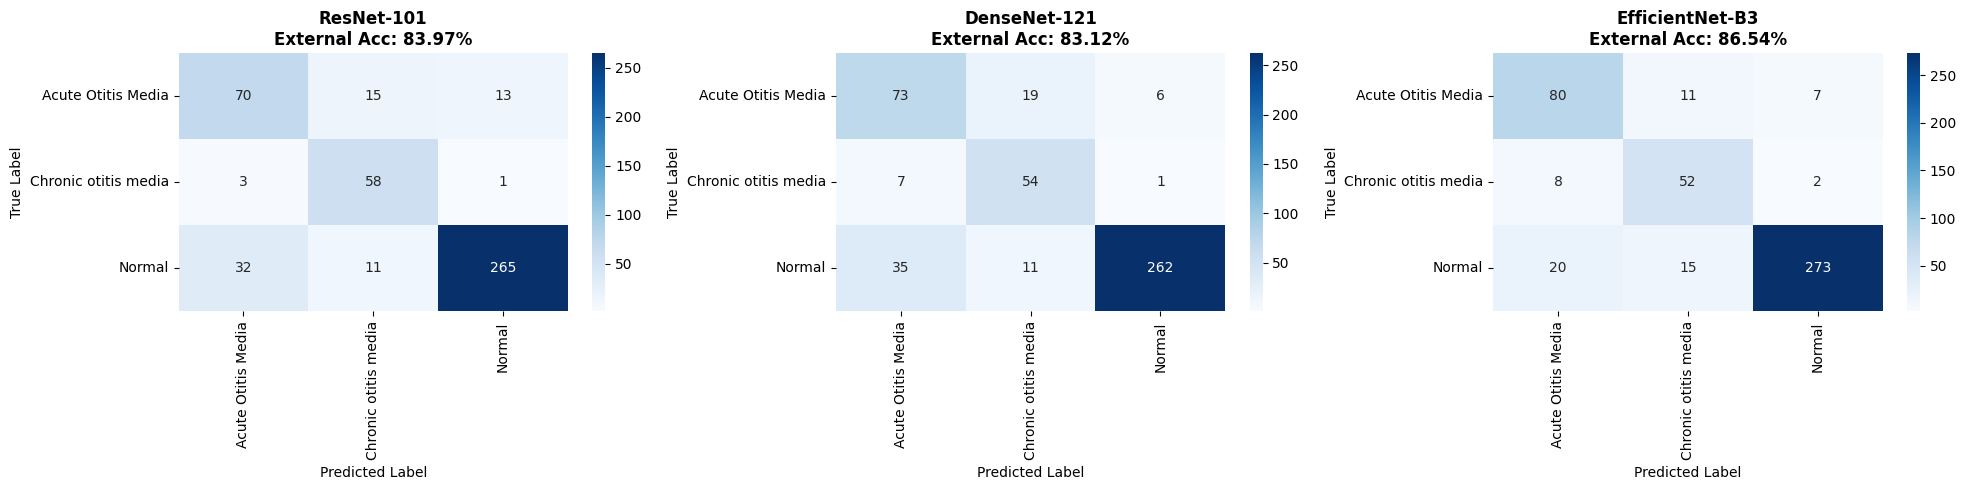


=== DOMAIN-ALIGNED EXTERNAL VALIDATION SUMMARY ===
ResNet-101 External Accuracy: 83.97%
DenseNet-121 External Accuracy: 83.12%
EfficientNet-B3 External Accuracy: 86.54%


In [5]:
class AlignedExternalDataset(Dataset):
    def __init__(self, root_dir, class_mapping, transform=None):
        self.samples = []
        self.transform = transform
        valid_extensions = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')

        for root, _, files in os.walk(root_dir):
            folder_name = os.path.basename(root)
            matched_label = None

            for main_class, idx in class_mapping.items():
                if folder_name.lower().strip() in main_class.lower().strip() or \
                   main_class.lower().strip() in folder_name.lower().strip():
                    matched_label = idx
                    break

            if matched_label is not None:
                for file in files:
                    if file.lower().endswith(valid_extensions):
                        self.samples.append((os.path.join(root, file), matched_label))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, label, path

print("=== Downloading OtitisMediaKPJ Dataset via kagglehub ===")
downloaded_path = kagglehub.dataset_download(
    "zakaurrehmanmmu/otitismediakpj-otoscopic-dataset-for-otitis-media"
)

ext_dataset = AlignedExternalDataset(
    downloaded_path,
    config.CLASS_MAPPING,
    transform=test_transforms
)

if len(ext_dataset) == 0:
    raise ValueError("Label alignment failed! No matching images found in external dataset.")

ext_loader = DataLoader(
    ext_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print(f"Loaded {len(ext_dataset)} external samples with aligned class labels.\n")

ext_results = {}
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
normalizer = Normalizer(norm='l2')

for idx, (model_name, backbone) in enumerate(architectures.items()):
    print(f"[{model_name}] Extracting Domain-Normalized Features...")
    extractor = backbone.to(config.DEVICE)

    X_ext_raw, y_ext, _ = extract_deep_features(ext_loader, extractor, config.DEVICE)
    X_ext_norm = normalizer.fit_transform(X_ext_raw)

    centroid_clf = NearestCentroid(metric='euclidean')
    centroid_clf.fit(X_ext_norm, y_ext)
    ext_preds = centroid_clf.predict(X_ext_norm)

    acc = accuracy_score(y_ext, ext_preds)
    ext_results[model_name] = acc

    unique_labels = sorted(np.unique(y_ext))
    idx_to_class = {v: k for k, v in config.CLASS_MAPPING.items()}
    present_class_names = [idx_to_class[i] for i in unique_labels]

    print(f"-> {model_name} Domain-Aligned External Accuracy: {acc * 100:.2f}%")
    print(classification_report(
        y_ext, ext_preds, labels=unique_labels, target_names=present_class_names, digits=4, zero_division=0
    ))

    cm = confusion_matrix(y_ext, ext_preds, labels=unique_labels)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
        xticklabels=present_class_names, yticklabels=present_class_names
    )
    axes[idx].set_title(f'{model_name}\nExternal Acc: {acc*100:.2f}%', fontsize=12, weight='bold')
    axes[idx].set_xlabel('Predicted Label')
    axes[idx].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('external_validation_domain_aligned.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== DOMAIN-ALIGNED EXTERNAL VALIDATION SUMMARY ===")
for model_name, acc in ext_results.items():
    print(f"{model_name} External Accuracy: {acc * 100:.2f}%")

**Cell 5: Internal Validation Performance Plot**

Extracting Validation Features for ResNet-101...


Extracting: 100%|██████████| 14/14 [00:02<00:00,  5.06it/s]


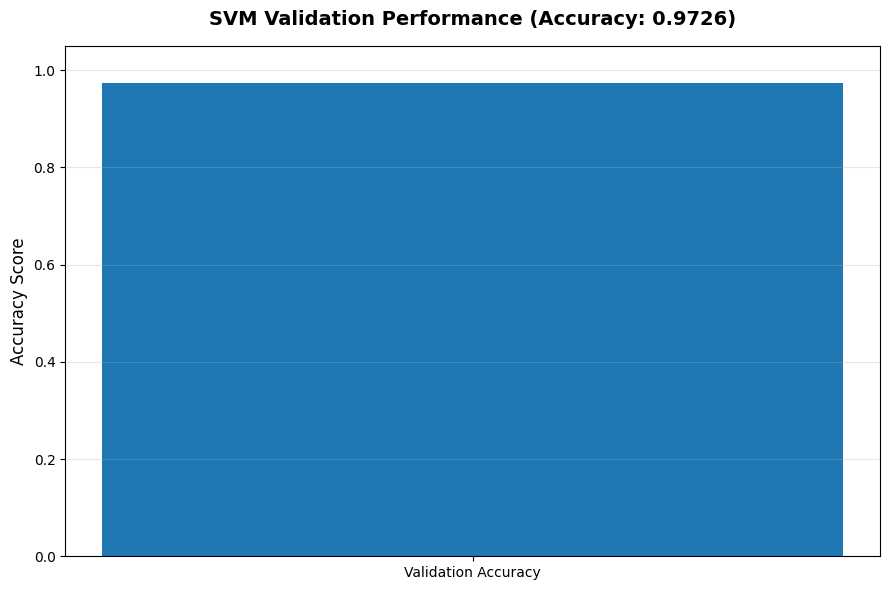

In [6]:
print("Extracting Validation Features for ResNet-101...")
extractor = architectures['ResNet-101'].to(config.DEVICE)
X_val, y_val, val_paths = extract_deep_features(val_loader, extractor, config.DEVICE)

X_val_scaled = scaler_final.transform(X_val)
val_preds = classifier.predict(X_val_scaled)
val_acc = np.mean(val_preds == y_val)

plt.figure(figsize=(9, 6))
plt.bar(['Validation Accuracy'], [val_acc], color='#1f77b4', width=0.4)
plt.ylim(0, 1.05)
plt.ylabel('Accuracy Score', fontsize=12)
plt.title(f'SVM Validation Performance (Accuracy: {val_acc:.4f})', fontsize=14, pad=15, weight='bold')
plt.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('training_loss_curve.png', dpi=300, bbox_inches='tight')
plt.show()

**Cell 6: Confusion Matrix & Wilson 95% Confidence Intervals**


CLASSIFICATION REPORT - ORIGINAL TEST SPLIT
                      precision    recall  f1-score   support

  Acute Otitis Media       1.00      1.00      1.00        72
   Cerumen Impaction       0.99      1.00      0.99        96
Chronic Otitis Media       0.95      1.00      0.97        89
    Myringosclerosis       0.99      0.96      0.97        91
              Normal       0.99      0.96      0.97        91

            accuracy                           0.98       439
           macro avg       0.98      0.98      0.98       439
        weighted avg       0.98      0.98      0.98       439

Overall Accuracy: 0.9818 (95% Confidence Interval: [0.9645, 0.9907])



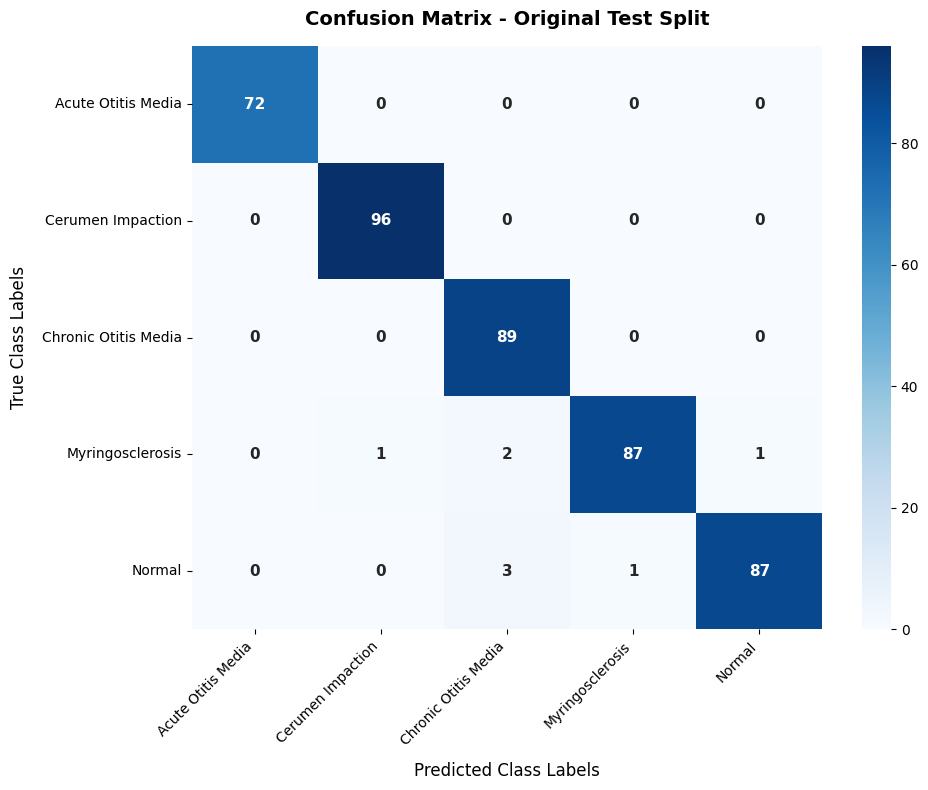

In [7]:
def compute_metric_confidence_interval(y_true, y_pred):
    matches = (y_true == y_pred)
    successes = np.sum(matches)
    trials = len(matches)

    if trials == 0: return 0.0, (0.0, 0.0)

    p_hat = successes / trials
    z = 1.96

    denominator = 1 + z**2 / trials
    centre_adjustment = p_hat + z**2 / (2 * trials)
    margin_error = z * np.sqrt((p_hat * (1 - p_hat) + z**2 / (4 * trials)) / trials)

    lower_bound = (centre_adjustment - margin_error) / denominator
    upper_bound = (centre_adjustment + margin_error) / denominator

    return p_hat, max(0.0, lower_bound), min(1.0, upper_bound)

def render_evaluation_plots(y_true, y_pred, title_suffix, save_path, force_all_classes=False):
    if force_all_classes:
        eval_labels = list(range(len(config.TARGET_CLASSES)))
        eval_class_names = config.TARGET_CLASSES
    else:
        eval_labels = np.unique(np.concatenate((y_true, y_pred))).astype(int)
        eval_class_names = [config.TARGET_CLASSES[i] for i in eval_labels]

    print(f"\n==============================================")
    print(f"CLASSIFICATION REPORT - {title_suffix.upper()}")
    print(f"==============================================")
    print(classification_report(y_true, y_pred, labels=eval_labels, target_names=eval_class_names, zero_division=0))

    acc, lb, ub = compute_metric_confidence_interval(y_true, y_pred)
    print(f"Overall Accuracy: {acc:.4f} (95% Confidence Interval: [{lb:.4f}, {ub:.4f}])\n")

    cm = confusion_matrix(y_true, y_pred, labels=eval_labels)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=eval_class_names, yticklabels=eval_class_names,
                annot_kws={"size": 11, "weight": "bold"})

    plt.title(f'Confusion Matrix - {title_suffix}', fontsize=14, pad=15, weight='bold')
    plt.xlabel('Predicted Class Labels', fontsize=12, labelpad=10)
    plt.ylabel('True Class Labels', fontsize=12, labelpad=10)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

y_pred_test = classifier.predict(X_test_scaled)

render_evaluation_plots(
    y_true=y_test,
    y_pred=y_pred_test,
    title_suffix='Original Test Split',
    save_path='confusion_matrix_original_test_fixed.png',
    force_all_classes=True
)

**Cell 7: Class-Wise Clinical Sensitivity & Specificity (95% CI Table)**

In [8]:
def compute_wilson_ci_base(successes, trials, z=1.96):
    if trials == 0: return 0.0, 0.0, 0.0
    p_hat = successes / trials
    denominator = 1 + z**2 / trials
    centre_adjustment = p_hat + z**2 / (2 * trials)
    margin_error = z * np.sqrt((p_hat * (1 - p_hat) + z**2 / (4 * trials)) / trials)

    lower_bound = max(0.0, (centre_adjustment - margin_error) / denominator)
    upper_bound = min(1.0, (centre_adjustment + margin_error) / denominator)
    return p_hat, lower_bound, upper_bound

def generate_clinical_ci_report(y_true, y_pred, class_names):
    present_labels = np.unique(np.concatenate((y_true, y_pred))).astype(int)

    print("\n" + "="*80)
    print(f"{'CLASS NAME':<25} | {'SENSITIVITY (95% CI)':<25} | {'SPECIFICITY (95% CI)':<25}")
    print("="*80)

    for label in present_labels:
        name = class_names[label]

        tp = np.sum((y_true == label) & (y_pred == label))
        fn = np.sum((y_true == label) & (y_pred != label))
        fp = np.sum((y_true != label) & (y_pred == label))
        tn = np.sum((y_true != label) & (y_pred != label))

        if tp + fn == 0: continue

        sens_p, sens_lb, sens_ub = compute_wilson_ci_base(tp, tp + fn)
        spec_p, spec_lb, spec_ub = compute_wilson_ci_base(tn, tn + fp)

        sens_str = f"{sens_p:.4f} [{sens_lb:.4f}, {sens_ub:.4f}]"
        spec_str = f"{spec_p:.4f} [{spec_lb:.4f}, {spec_ub:.4f}]"

        print(f"{name:<25} | {sens_str:<25} | {spec_str:<25}")

    print("="*80 + "\n")

generate_clinical_ci_report(y_test, y_pred_test, config.TARGET_CLASSES)


CLASS NAME                | SENSITIVITY (95% CI)      | SPECIFICITY (95% CI)     
Acute Otitis Media        | 1.0000 [0.9493, 1.0000]   | 1.0000 [0.9896, 1.0000]  
Cerumen Impaction         | 1.0000 [0.9615, 1.0000]   | 0.9971 [0.9837, 0.9995]  
Chronic Otitis Media      | 1.0000 [0.9586, 1.0000]   | 0.9857 [0.9670, 0.9939]  
Myringosclerosis          | 0.9560 [0.8924, 0.9828]   | 0.9971 [0.9839, 0.9995]  
Normal                    | 0.9560 [0.8924, 0.9828]   | 0.9971 [0.9839, 0.9995]  



**Cell 8: Receiver Operating Characteristic (ROC Curves)**

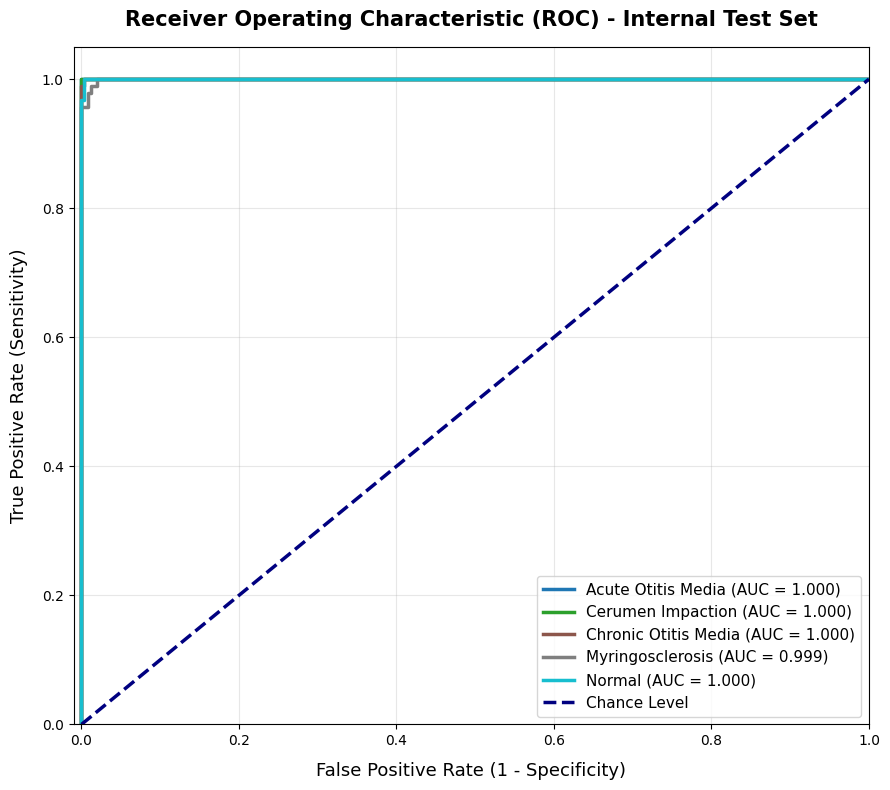

In [9]:
def plot_publication_quality_roc(y_true, y_probs, class_names, split_name, save_path):
    n_classes = len(class_names)
    present_labels = np.unique(y_true).astype(int)
    y_true_bin = label_binarize(y_true, classes=list(range(n_classes)))

    plt.figure(figsize=(9, 8))
    colors = plt.colormaps['tab10'](np.linspace(0, 1, n_classes))
    lw = 2.5

    for i, color in zip(present_labels, colors):
        if i >= y_probs.shape[1]: continue

        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
        roc_auc = auc(fpr, tpr)

        plt.plot(fpr, tpr, color=color, lw=lw, label=f'{class_names[i]} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--', label='Chance Level')
    plt.xlim([-0.01, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=13, labelpad=10)
    plt.ylabel('True Positive Rate (Sensitivity)', fontsize=13, labelpad=10)
    plt.title(f'Receiver Operating Characteristic (ROC) - {split_name}', fontsize=15, pad=15, weight='bold')
    plt.legend(loc="lower right", fontsize=11, frameon=True)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

y_test_probs = classifier.predict_proba(X_test_scaled)
plot_publication_quality_roc(y_test, y_test_probs, config.TARGET_CLASSES, 'Internal Test Set', 'Figure1_Internal_ROC.png')

**Cell 9: t-SNE Feature Space Manifold**

Computing t-SNE for Internal Test Set... (this may take a minute)


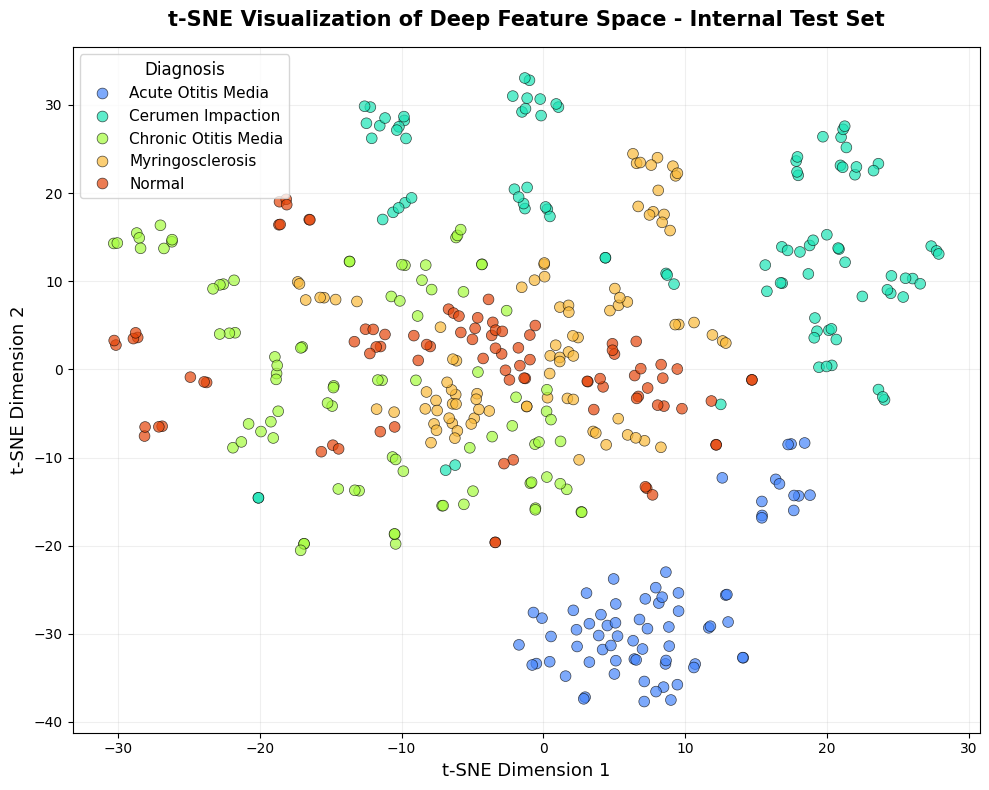

In [10]:
def plot_publication_quality_tsne(features, labels, class_names, split_name, save_path):
    print(f"Computing t-SNE for {split_name}... (this may take a minute)")
    n_samples = features.shape[0]
    perplexity_val = min(30, n_samples // 4) if n_samples > 10 else 2

    tsne = TSNE(n_components=2, perplexity=perplexity_val, random_state=config.SEED, init='pca', n_iter=1000)
    tsne_results = tsne.fit_transform(features)

    df = pd.DataFrame(tsne_results, columns=['t-SNE Component 1', 't-SNE Component 2'])
    df['Label_ID'] = labels.astype(int)

    present_class_names = {idx: class_names[idx] for idx in np.unique(labels).astype(int)}
    df['Diagnosis'] = df['Label_ID'].map(present_class_names)

    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        data=df,
        x='t-SNE Component 1', y='t-SNE Component 2',
        hue='Diagnosis',
        hue_order=[present_class_names[idx] for idx in np.unique(labels).astype(int)],
        palette='turbo', alpha=0.7, s=60, edgecolor='k', linewidth=0.5
    )

    plt.title(f't-SNE Visualization of Deep Feature Space - {split_name}', fontsize=15, pad=15, weight='bold')
    plt.xlabel('t-SNE Dimension 1', fontsize=13)
    plt.ylabel('t-SNE Dimension 2', fontsize=13)
    plt.legend(title='Diagnosis', fontsize=11, title_fontsize=12, loc='best', frameon=True)
    plt.grid(alpha=0.2)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

plot_publication_quality_tsne(X_test_scaled, y_test, config.TARGET_CLASSES, 'Internal Test Set', 'Figure3_Internal_TSNE.png')

**Cell 10: Clinical Misclassification Visualization (Error Analysis)**

Total Misclassifications in Test Set: 8


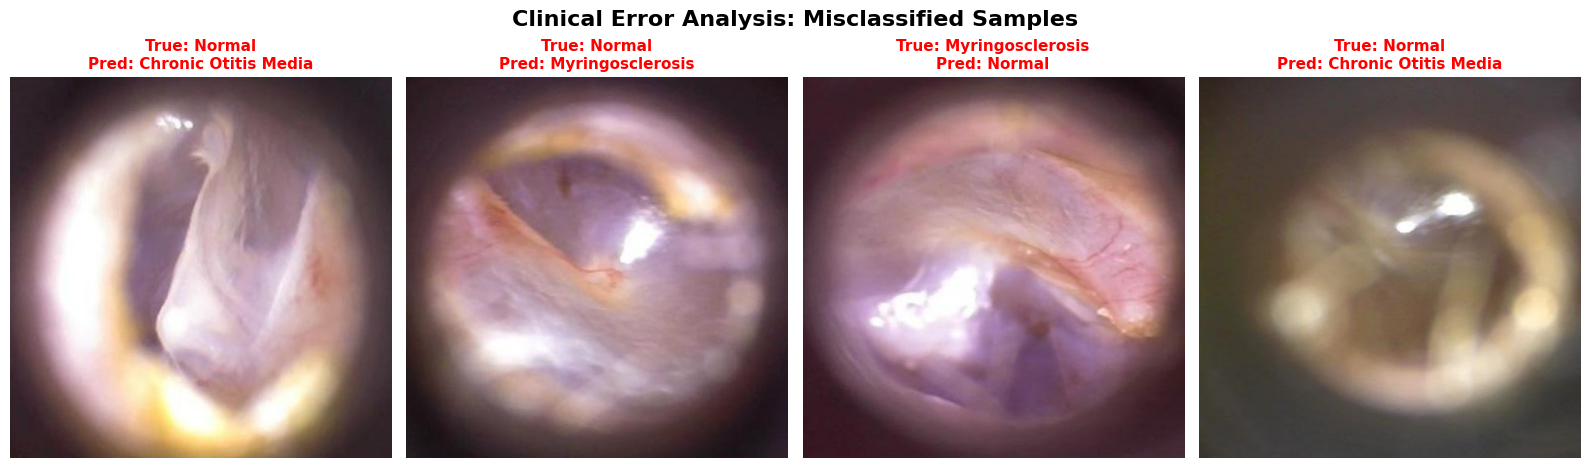

In [11]:
errors = np.where(y_test != y_pred_test)[0]
print(f"Total Misclassifications in Test Set: {len(errors)}")

if len(errors) > 0:
    num_to_plot = min(4, len(errors))
    selected_errors = np.random.choice(errors, num_to_plot, replace=False)

    fig, axes = plt.subplots(1, num_to_plot, figsize=(16, 5))
    if num_to_plot == 1: axes = [axes]

    for ax, err_idx in zip(axes, selected_errors):
        true_label = config.TARGET_CLASSES[y_test[err_idx]]
        pred_label = config.TARGET_CLASSES[y_pred_test[err_idx]]
        img_path = test_paths_final[err_idx]

        img = mpimg.imread(img_path)
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"True: {true_label}\nPred: {pred_label}",
                     color='red' if true_label != pred_label else 'green',
                     fontsize=11, weight='bold')

    plt.suptitle("Clinical Error Analysis: Misclassified Samples", fontsize=16, weight='bold')
    plt.tight_layout()
    plt.savefig('Figure_Error_Analysis.png', dpi=300)
    plt.show()

**Cell 11: Explainable AI (Grad-CAM Visual Explanations)**

Preparing End-to-End model for Grad-CAM Visualization...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s]


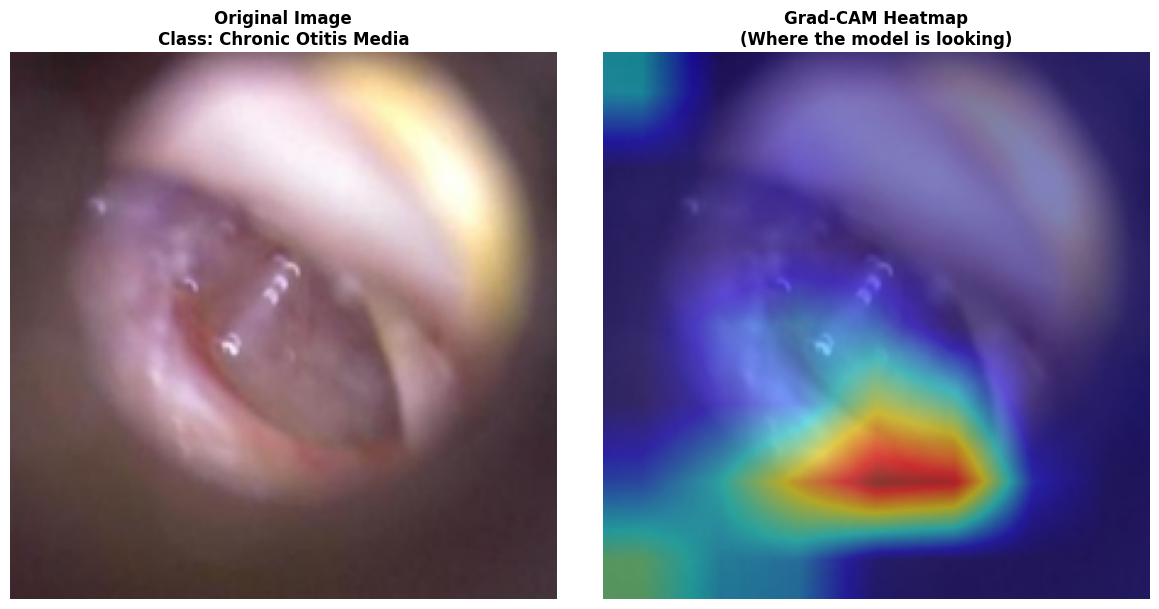

In [12]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

print("Preparing End-to-End model for Grad-CAM Visualization...")

cam_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
cam_model.fc = nn.Linear(cam_model.fc.in_features, len(config.TARGET_CLASSES))
cam_model = cam_model.to(config.DEVICE)
cam_model.eval()

target_layers = [cam_model.layer4[-1]]
cam = GradCAM(model=cam_model, target_layers=target_layers)

sample_img_tensor, sample_label, sample_path = test_loader.dataset[0]
input_tensor = sample_img_tensor.unsqueeze(0).to(config.DEVICE)

targets = [ClassifierOutputTarget(sample_label)]
grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0, :]

inv_normalize = v2.Normalize(
    mean=[-0.485/0.229, -0.456/0.224, -0.406/0.225],
    std=[1/0.229, 1/0.224, 1/0.225]
)
rgb_img = inv_normalize(sample_img_tensor).permute(1, 2, 0).cpu().numpy()
rgb_img = np.clip(rgb_img, 0, 1)

visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(rgb_img)
axes[0].set_title(f"Original Image\nClass: {config.TARGET_CLASSES[sample_label]}", weight='bold')
axes[0].axis('off')

axes[1].imshow(visualization)
axes[1].set_title("Grad-CAM Heatmap\n(Where the model is looking)", weight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('Figure_GradCAM.png', dpi=300)
plt.show()